# BERTweet Fine-tuning — Mental Health Sentiment Analysis

End-to-end notebook:
1. Environment check
2. Config & path setup
3. Preprocessing (if needed)
4. Data loaders
5. Model, optimiser & scheduler
6. Training loop
7. Training curves
8. Evaluation on test split


## 1 — Environment check

In [10]:
import subprocess, sys, importlib

REQUIRED = ['torch', 'transformers', 'sklearn', 'tqdm', 'yaml', 'pandas', 'matplotlib', 'seaborn']
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}  '
      f'({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"})')


PyTorch : 2.10.0+cu128
CUDA    : True  (NVIDIA GeForce RTX 3060)


## 2 — Config & path setup

Edit the commented-out overrides to change settings without touching the YAML.

In [11]:
import sys, os
from pathlib import Path

# Notebook should sit at the project root; adjust if you moved it
PROJECT_ROOT = Path('/home/sakana/Code/PTIT/NLP/sentimind')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print('Working dir:', PROJECT_ROOT)


Working dir: /home/sakana/Code/PTIT/NLP/sentimind


In [12]:
import yaml, json

with open('configs/bertweet.yaml') as f:
    cfg = yaml.safe_load(f)

# ── Optional overrides (uncomment to activate) ──────────────────────────────
# cfg['training']['epochs'] = 3          # quick smoke-test
cfg['training']['fp16'] = True          # enable if CUDA GPU available
# cfg['model']['freeze_base'] = True      # head-only training (faster)
# ─────────────────────────────────────────────────────────────────────────────

print(json.dumps(cfg, indent=2))


{
  "seed": 42,
  "data": {
    "train_path": "data/processed/train.csv",
    "val_path": "data/processed/val.csv",
    "test_path": "data/processed/test.csv",
    "text_col": "text",
    "label_col": "label_id",
    "max_seq_len": 128
  },
  "model": {
    "pretrained_name": "vinai/bertweet-base",
    "num_classes": 7,
    "dropout": 0.1,
    "freeze_base": false
  },
  "training": {
    "batch_size": 16,
    "gradient_accumulation_steps": 2,
    "epochs": 10,
    "learning_rate": 2e-05,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "class_weighted_loss": true,
    "early_stopping_patience": 3,
    "early_stopping_metric": "macro_f1",
    "gradient_clip": 1.0,
    "fp16": true
  },
  "output": {
    "artifacts_dir": "data/artifacts",
    "checkpoint_name": "bertweet_best.pt",
    "metrics_name": "bertweet_metrics.json",
    "confusion_matrix_name": "bertweet_confusion_matrix.png",
    "history_name": "bertweet_train_history.json"
  }
}


In [13]:
import torch
from src.training.trainer import set_seed

SEED = cfg['seed']
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)

data_cfg  = cfg['data']
model_cfg = cfg['model']
train_cfg = cfg['training']
out_cfg   = cfg['output']

ARTIFACTS_DIR = Path(out_cfg['artifacts_dir'])
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


Device : cuda


## 3 — Preprocessing (if needed)

Runs `scripts/preprocess.py` only when `data/processed/*.csv` is missing.

In [5]:
train_csv = Path(data_cfg['train_path'])

if not train_csv.exists():
    print('Processed data not found — running preprocess.py ...')
    result = subprocess.run(
        [sys.executable, 'scripts/preprocess.py', '--config', 'configs/preprocessing.yaml'],
        capture_output=True, text=True,
    )
    print(result.stdout[-3000:] if result.stdout else '')
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
        raise RuntimeError('Preprocessing failed — see output above')
else:
    print(f'Processed data already at {train_csv.parent}')

import pandas as pd
for split, path in [('train', data_cfg['train_path']),
                    ('val',   data_cfg['val_path']),
                    ('test',  data_cfg['test_path'])]:
    df = pd.read_csv(path)
    print(f'  {split:5s}: {len(df):6,} rows  |  columns: {list(df.columns)}')


Processed data already at data/processed
  train: 35,731 rows  |  columns: ['text', 'label', 'label_id']
  val  :  7,657 rows  |  columns: ['text', 'label', 'label_id']
  test :  7,657 rows  |  columns: ['text', 'label', 'label_id']


## 4 — Data loaders

In [18]:
from src.data.bertweet_dataset import build_transformer_loaders

train_loader, val_loader, test_loader = build_transformer_loaders(
    train_path=data_cfg['train_path'],
    val_path=data_cfg['val_path'],
    test_path=data_cfg['test_path'],
    model_name=model_cfg['pretrained_name'],
    max_len=data_cfg['max_seq_len'],
    batch_size=train_cfg['batch_size'],
    seed=SEED,
)

print(f'Batches — train: {len(train_loader):,}  val: {len(val_loader):,}  test: {len(test_loader):,}')
sample = next(iter(train_loader))
print('Batch keys :', list(sample.keys()))
print('input_ids  :', sample['input_ids'].shape)
print('labels     :', sample['labels'][:8].tolist())


Batches — train: 2,234  val: 479  test: 479
Batch keys : ['input_ids', 'attention_mask', 'labels']
input_ids  : torch.Size([16, 128])
labels     : [3, 6, 6, 6, 6, 6, 1, 0]


In [19]:
import numpy as np

num_classes   = model_cfg['num_classes']
class_weights = None

if train_cfg.get('class_weighted_loss', True):
    df_train = pd.read_csv(data_cfg['train_path'])
    counts = np.zeros(num_classes)
    for lbl, cnt in df_train['label_id'].value_counts().items():
        counts[int(lbl)] = cnt
    counts = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.sum()
    class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    from src.data.preprocess import ID_TO_LABEL
    print('Class weights:')
    for i, w in enumerate(weights):
        print(f'  [{i}] {ID_TO_LABEL.get(i, "?"):25s} count={int(counts[i]):6,}  weight={w:.4f}')


Class weights:
  [0] Normal                    count=11,205  weight=0.0255
  [1] Depression                count=10,565  weight=0.0270
  [2] Anxiety                   count= 2,534  weight=0.1126
  [3] Bipolar                   count= 1,751  weight=0.1629
  [4] Personality Disorder      count=   626  weight=0.4558
  [5] Stress                    count= 1,604  weight=0.1779
  [6] Suicidal                  count= 7,446  weight=0.0383


## 5 — Model, optimiser & scheduler

In [16]:
from src.models.bertweet import BERTweetClassifier

model = BERTweetClassifier(
    model_name=model_cfg['pretrained_name'],
    num_classes=num_classes,
    dropout=model_cfg['dropout'],
    freeze_base=model_cfg.get('freeze_base', False),
)
model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parameters: {trainable:,} trainable / {total:,} total  ({trainable/total*100:.1f}%)')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 86034.77it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

Parameters: 134,905,351 trainable / 134,905,351 total  (100.0%)


In [20]:
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup
from src.training.trainer import EarlyStopping

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=train_cfg['learning_rate'],
    weight_decay=train_cfg['weight_decay'],
)

ACCUM_STEPS = train_cfg.get('gradient_accumulation_steps', 1)
EPOCHS      = train_cfg['epochs']

total_steps  = (len(train_loader) // ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * train_cfg.get('warmup_ratio', 0.06))

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

USE_FP16 = train_cfg.get('fp16') and DEVICE.type == 'cuda'
scaler   = torch.cuda.amp.GradScaler() if USE_FP16 else None

early_stopping = EarlyStopping(
    patience=train_cfg['early_stopping_patience'],
    mode='max' if train_cfg['early_stopping_metric'] == 'macro_f1' else 'min',
)

CHECKPOINT_PATH = ARTIFACTS_DIR / out_cfg['checkpoint_name']

print(f'Total update steps : {total_steps:,}  (warmup: {warmup_steps})')
print(f'Effective batch    : {train_cfg["batch_size"] * ACCUM_STEPS}')
print(f'fp16               : {USE_FP16}')


Total update steps : 11,170  (warmup: 670)
Effective batch    : 32
fp16               : True


/tmp/ipykernel_44184/2575209845.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler   = torch.cuda.amp.GradScaler() if USE_FP16 else None


## 6 — Training loop

In [21]:
import time
from tqdm.auto import tqdm
from sklearn.metrics import f1_score


def _train_epoch(model, loader, optimizer, criterion, device,
                 grad_clip, accum_steps, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(loader, desc='  train', leave=False), start=1):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        if scaler:
            with torch.autocast(device_type=device.type):
                logits = model(ids, mask)
                loss   = criterion(logits, lbls) / accum_steps
            scaler.scale(loss).backward()
        else:
            logits = model(ids, mask)
            loss   = criterion(logits, lbls) / accum_steps
            loss.backward()
        preds = logits.detach().argmax(dim=-1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)
        total_loss += loss.item() * accum_steps * lbls.size(0)
        if step % accum_steps == 0 or step == len(loader):
            if scaler:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    return total_loss / total, correct / total


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []
    for batch in tqdm(loader, desc='  eval ', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbls = batch['labels'].to(device)
        logits = model(ids, mask)
        loss   = criterion(logits, lbls)
        total_loss += loss.item() * lbls.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == lbls).sum().item()
        total   += lbls.size(0)
        y_true.extend(lbls.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1, y_true, y_pred


print('Helper functions defined.')


Helper functions defined.


In [22]:
GRAD_CLIP   = train_cfg.get('gradient_clip', 1.0)
best_metric = float('-inf')
history     = []
t0          = time.time()

for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()

    tr_loss, tr_acc = _train_epoch(
        model, train_loader, optimizer, criterion,
        DEVICE, GRAD_CLIP, ACCUM_STEPS, scaler,
    )
    val_loss, val_acc, val_f1, _, _ = _eval_epoch(
        model, val_loader, criterion, DEVICE,
    )

    monitor = val_f1 if train_cfg['early_stopping_metric'] == 'macro_f1' else -val_loss

    history.append({
        'epoch': epoch,
        'tr_loss': round(tr_loss, 4), 'tr_acc': round(tr_acc, 4),
        'val_loss': round(val_loss, 4), 'val_acc': round(val_acc, 4),
        'val_f1': round(val_f1, 4), 'time_s': round(time.time() - t_ep, 1),
    })

    print(
        f'Epoch {epoch:02d}/{EPOCHS}  '
        f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
        f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  '
        f'[{time.time()-t_ep:.0f}s]'
    )

    if monitor > best_metric:
        best_metric = monitor
        model.save_checkpoint(CHECKPOINT_PATH, epoch=epoch, best_metric=best_metric)
        print(f'  Checkpoint saved  (best val_f1={best_metric:.4f})')

    if early_stopping(monitor, epoch):
        print(f'\nEarly stopping at epoch {epoch}  (best epoch {early_stopping.best_epoch})')
        break

print(f'\nTraining done in {time.time()-t0:.1f}s  |  Best val_f1 = {best_metric:.4f}')
history_path = ARTIFACTS_DIR / out_cfg['history_name']
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'History saved -> {history_path}')


KeyboardInterrupt: 

## 7 — Training curves

Loaded history from data/artifacts/bertweet_train_history.json  (8 epochs)


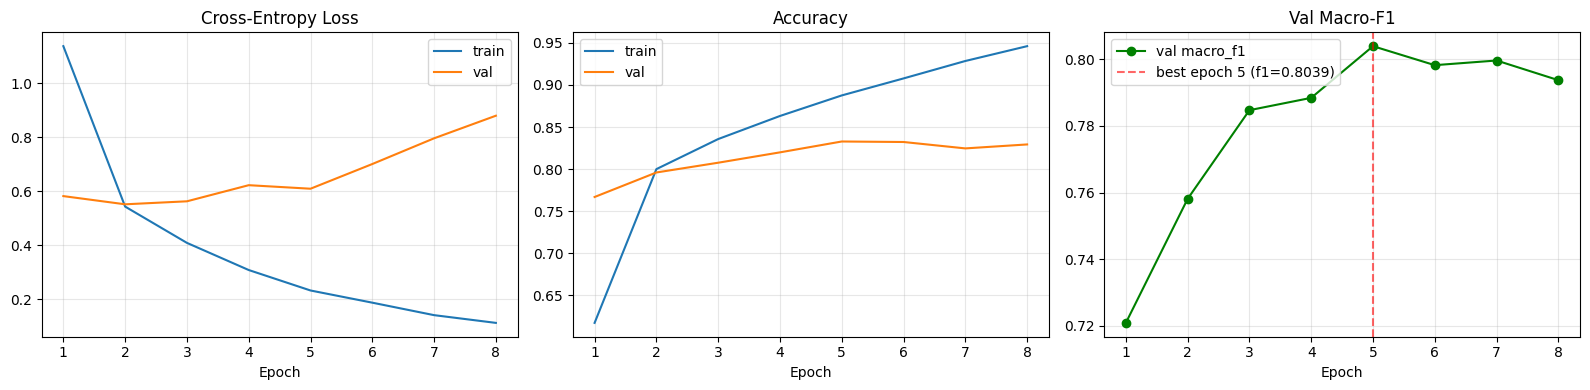

Curves saved -> data/artifacts/bertweet_train_curves.png


In [24]:
import sys, os, json
import matplotlib.pyplot as plt
from pathlib import Path

# ── self-contained setup ─────────────────────────────────────────────────────
if 'cfg' not in dir():
    import yaml
    PROJECT_ROOT = Path('/home/sakana/Code/PTIT/NLP/sentimind')
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    os.chdir(PROJECT_ROOT)
    with open('configs/bertweet.yaml') as _f:
        cfg = yaml.safe_load(_f)

if 'out_cfg' not in dir():
    out_cfg = cfg['output']

if 'ARTIFACTS_DIR' not in dir():
    ARTIFACTS_DIR = Path(out_cfg['artifacts_dir'])

if 'history' not in dir() or not history:
    history_path = ARTIFACTS_DIR / out_cfg['history_name']
    with open(history_path) as _f:
        history = json.load(_f)
    print(f'Loaded history from {history_path}  ({len(history)} epochs)')
# ─────────────────────────────────────────────────────────────────────────────

epochs_ax = [r['epoch']    for r in history]
tr_losses = [r['tr_loss']  for r in history]
va_losses = [r['val_loss'] for r in history]
tr_accs   = [r['tr_acc']   for r in history]
va_accs   = [r['val_acc']  for r in history]
va_f1s    = [r['val_f1']   for r in history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ax, tr_losses, label='train')
axes[0].plot(epochs_ax, va_losses, label='val')
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ax, tr_accs, label='train')
axes[1].plot(epochs_ax, va_accs, label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ax, va_f1s, color='green', marker='o', label='val macro_f1')
best_ep = max(history, key=lambda r: r['val_f1'])
axes[2].axvline(best_ep['epoch'], linestyle='--', color='red', alpha=0.6,
                label=f'best epoch {best_ep["epoch"]} (f1={best_ep["val_f1"]:.4f})')
axes[2].set_title('Val Macro-F1'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
curves_path = ARTIFACTS_DIR / 'bertweet_train_curves.png'
plt.savefig(curves_path, dpi=150)
plt.show()
print(f'Curves saved -> {curves_path}')


In [26]:
import pandas as pd
df_hist = pd.DataFrame(history).set_index('epoch')
df_hist.style \
    .highlight_max(subset=['val_acc', 'val_f1'], color="#3ab152") \
    .highlight_min(subset=['tr_loss', 'val_loss'], color="#4b0f4d") \
    .format({c: '{:.4f}' for c in df_hist.columns if c != 'time_s'})


,tr_loss,tr_acc,val_loss,val_acc,val_f1,time_s
epoch,,,,,,
1,1.1380,0.6174,0.5818,0.7669,0.7209,259.000000
2,0.5429,0.8000,0.5514,0.7960,0.7581,259.800000
3,0.4083,0.8357,0.5625,0.8076,0.7847,259.800000
4,0.3076,0.8631,0.6223,0.8199,0.7884,259.800000
5,0.2317,0.8875,0.6092,0.8328,0.8039,259.800000
6,0.1865,0.9077,0.7008,0.8322,0.7982,259.800000
7,0.1402,0.9284,0.7962,0.8246,0.7996,259.800000
8,0.1115,0.9460,0.8800,0.8293,0.7937,259.700000


## 8 — Evaluation on test split

In [2]:
import sys, os
import torch
import yaml
from pathlib import Path
from tqdm import tqdm
from src.models.bertweet import BERTweetClassifier
from src.utils.metrics import compute_metrics, save_metrics, save_confusion_matrix_plot
from src.data.preprocess import ID_TO_LABEL

# ── self-contained setup (runs when preceding cells were not executed) ────────
if 'cfg' not in dir():
    PROJECT_ROOT = Path('/home/sakana/Code/PTIT/NLP/sentimind')
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    os.chdir(PROJECT_ROOT)
    with open('configs/bertweet.yaml') as _f:
        cfg = yaml.safe_load(_f)

if 'DEVICE' not in dir():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'out_cfg' not in dir():
    out_cfg = cfg['output']

if 'model_cfg' not in dir():
    model_cfg = cfg['model']

if 'ARTIFACTS_DIR' not in dir():
    ARTIFACTS_DIR = Path(out_cfg['artifacts_dir'])

CHECKPOINT_PATH = ARTIFACTS_DIR / out_cfg['checkpoint_name']

if 'test_loader' not in dir():
    from src.data.bertweet_dataset import build_transformer_loaders
    data_cfg = cfg['data']
    train_cfg = cfg['training']
    _, _, test_loader = build_transformer_loaders(
        train_path=data_cfg['train_path'],
        val_path=data_cfg['val_path'],
        test_path=data_cfg['test_path'],
        model_name=model_cfg['pretrained_name'],
        max_len=data_cfg['max_seq_len'],
        batch_size=train_cfg['batch_size'],
        seed=cfg['seed'],
    )
# ─────────────────────────────────────────────────────────────────────────────

best_model = BERTweetClassifier.from_checkpoint(CHECKPOINT_PATH, device=DEVICE)
print(f'Loaded checkpoint: {CHECKPOINT_PATH}')

y_true, y_pred = [], []
best_model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='test inference'):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        logits = best_model(ids, mask)
        preds  = logits.argmax(dim=-1)
        y_true.extend(lbls.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

metrics = compute_metrics(y_true, y_pred, label_names=ID_TO_LABEL,
                          model_name='bertweet', split='test')
metrics_path = ARTIFACTS_DIR / out_cfg['metrics_name']
save_metrics(metrics, metrics_path)

cm_path = ARTIFACTS_DIR / out_cfg['confusion_matrix_name']
save_confusion_matrix_plot(metrics['confusion_matrix'], ID_TO_LABEL,
                           cm_path, title='BERTweet - Test Confusion Matrix')

print(f'\n{"="*45}')
print(f'  Accuracy    : {metrics["accuracy"]:.4f}')
print(f'  Macro  F1   : {metrics["macro_f1"]:.4f}')
print(f'  Weighted F1 : {metrics["weighted_f1"]:.4f}')
print(f'{"="*45}')
print(f'Metrics -> {metrics_path}')
print(f'Confusion matrix -> {cm_path}')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 84624.94it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok 

Loaded checkpoint: data/artifacts/bertweet_best.pt


test inference: 100%|██████████| 479/479 [00:27<00:00, 17.25it/s]



  Accuracy    : 0.8155
  Macro  F1   : 0.7831
  Weighted F1 : 0.8167
Metrics -> data/artifacts/bertweet_metrics.json
Confusion matrix -> data/artifacts/bertweet_confusion_matrix.png


In [5]:
import pandas as pd
per_class = metrics['per_class']

# per_class keys are label names (e.g. "Normal"), not numeric ids
name_to_id = {v.title(): k for k, v in ID_TO_LABEL.items()}
rows = []
for label_name, class_metrics in sorted(per_class.items(),
                                         key=lambda x: name_to_id.get(x[0], 99)):
    label_id = name_to_id.get(label_name, -1)
    rows.append({'label_id': label_id, 'label': label_name, **class_metrics})

df_pc = pd.DataFrame(rows).set_index('label_id')
df_pc.style \
    .background_gradient(subset=['f1'], cmap='RdYlGn') \
    .format({'precision': '{:.3f}', 'recall': '{:.3f}',
             'f1': '{:.3f}', 'support': '{:,.0f}'})


,label,precision,recall,f1,support
label_id,,,,,
0,Normal,0.964,0.943,0.954,"2,401"
1,Depression,0.805,0.694,0.745,"2,264"
2,Anxiety,0.870,0.871,0.870,543
3,Bipolar,0.811,0.845,0.828,375
4,Personality Disorder,0.591,0.702,0.642,134
5,Stress,0.652,0.794,0.716,344
6,Suicidal,0.679,0.784,0.728,"1,596"


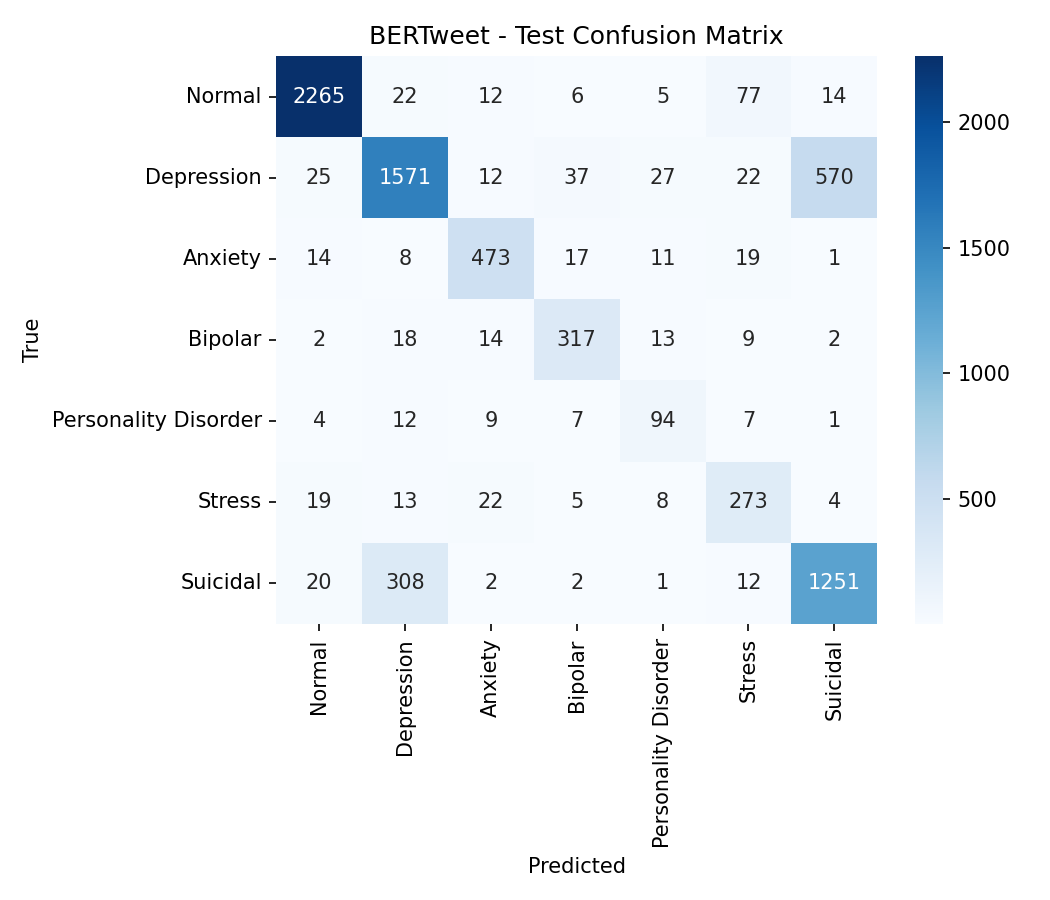

In [6]:
from IPython.display import Image
Image(str(cm_path), width=700)
